In [172]:
from show_img import show_img
import numpy as np
import cv2

In [173]:
red = [0, 0, 255]
green = [0, 255, 0]
blue = [255, 0, 0]

## 1. Детекторы Харриса и Ши Томаси

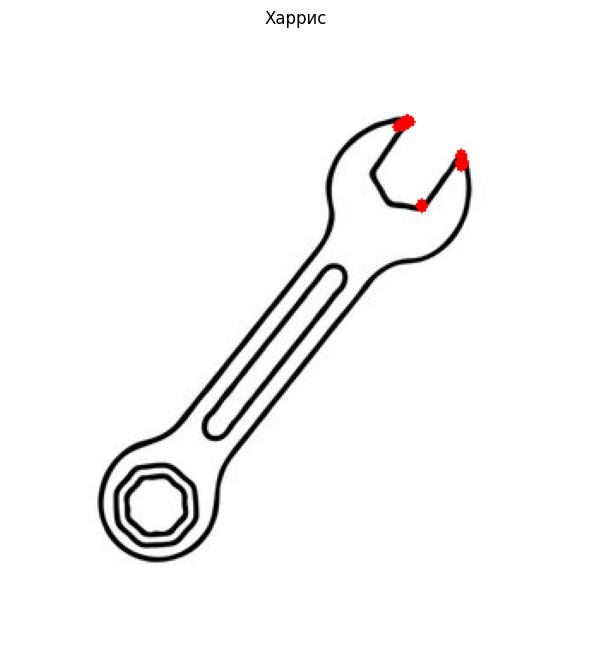

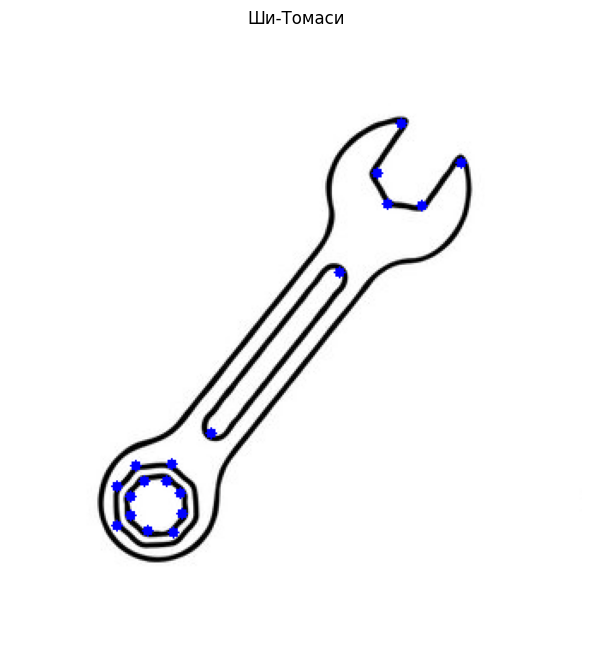

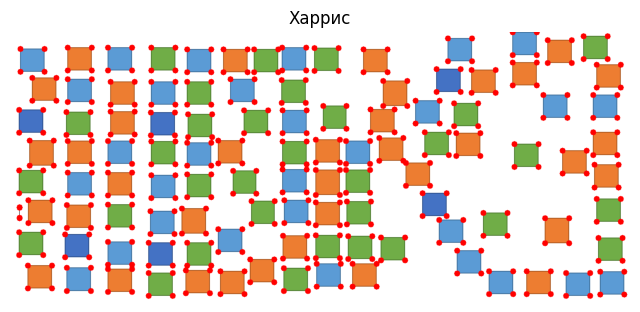

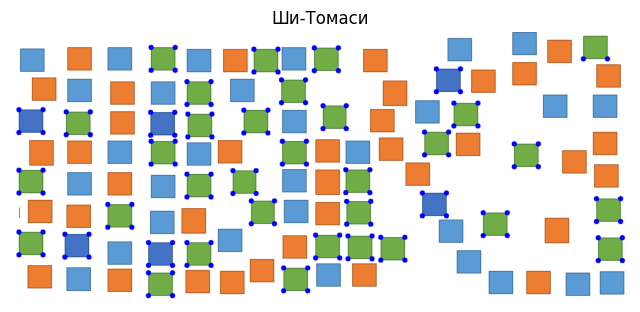

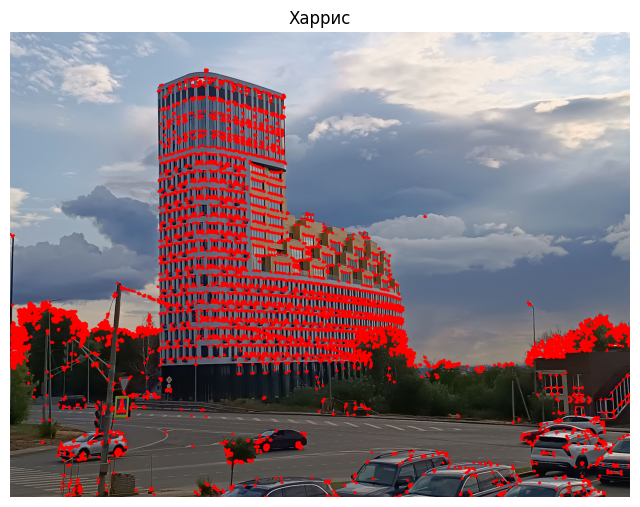

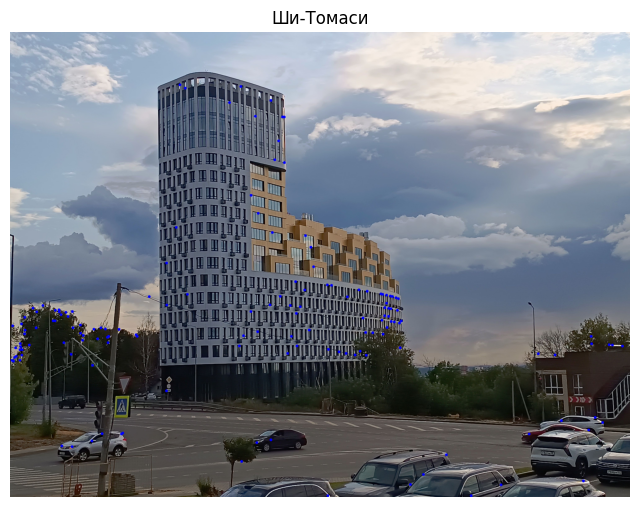

In [174]:
def detect_corners(img, size_mlt):
    img_shi = img.copy()
    img_grayscale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    points = cv2.cornerHarris(img_grayscale, 2, 3, 0.04)
    thres = 0.01
    y_coords, x_coords = np.where(points > thres * points.max())
    for x, y in zip(x_coords, y_coords):
        cv2.circle(img, (x, y), 3 * size_mlt, red, -1)
    img[points > thres * points.max()] = red


    corners = cv2.goodFeaturesToTrack(img_grayscale, 150, 0.01, 10)
    corners = corners.astype(int) 
    
    for i in corners:
        x, y = i.ravel()
        cv2.circle(img_shi, (x, y), 3 * size_mlt, blue, -1)

    show_img(img, "Харрис", size=8)
    show_img(img_shi, "Ши-Томаси", size=8)


images = ['spanner.png', 
          "square_many2.jpg",
          "skyskeb_one.jpg", 
          ]


for i, img_path in enumerate(images):
    img1 = cv2.imread(img_path)
    if img_path == "skskyskeb_one.jpgy": i *= 2
    detect_corners(img1, i + 1)

## 3. Шаблон объекта

Coord 0, x 2.64, y 19.15, angle 248.17
Coord 1, x 5.79, y 87.34, angle 119.60
Coord 2, x 10.48, y 89.40, angle 110.04
Coord 3, x 25.96, y 17.04, angle 90.36
Coord 4, x 25.96, y 17.04, angle 172.02


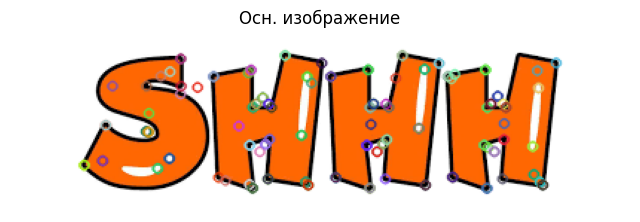

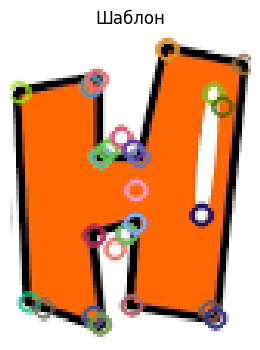

In [175]:
img3_orig = cv2.imread("shhh.png")
img = img3_orig.copy()
template = img[10:110, 134:212]

sift = cv2.SIFT_create()
kp_i, des_i = sift.detectAndCompute(img, None)
kp_t, des_t = sift.detectAndCompute(template, None)

img_kp = cv2.drawKeypoints(img, kp_i, None, flags=0)
template_kp = cv2.drawKeypoints(template, kp_t, None, flags=0)

for i in range(min(5, len(kp_t))):
    x, y = kp_t[i].pt
    angle = kp_t[i].angle
    print(f"Coord {i}, x {x:.2f}, y {y:.2f}, angle {angle:.2f}")

show_img(img_kp, "Осн. изображение", size=8)
show_img(template_kp, "Шаблон", size=4)

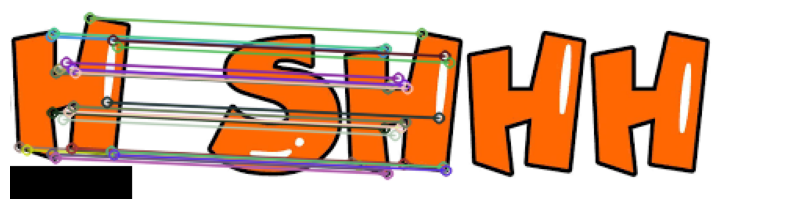

In [176]:
bf = cv2.BFMatcher(cv2.NORM_L2)
matches = bf.knnMatch(des_t, des_i, k=2)

good = []
coef = 0.95
for m, n in matches:
    if m.distance < n.distance * coef:
        good.append([m])

img3 = cv2.drawMatchesKnn(template, kp_t, img, kp_i, good, None, flags=2)
show_img(img3)

Пара 0, 
шаблон x 5.8, y 87.3 
 осн: x 139.8, y 97.3
Пара 1, 
шаблон x 10.5, y 89.4 
 осн: x 144.5, y 99.4
Пара 2, 
шаблон x 26.0, y 17.0 
 осн: x 160.0, y 27.0


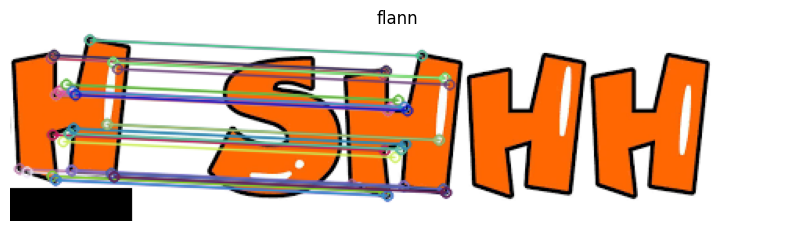

In [177]:
img = img3_orig.copy()
template = img[10:110, 134:212]

sift = cv2.SIFT_create()
kp_i, des_i = sift.detectAndCompute(img, None)
kp_t, des_t = sift.detectAndCompute(template, None)

img_kp = cv2.drawKeypoints(img, kp_i, None, flags=0)
template_kp = cv2.drawKeypoints(template, kp_t, None, flags=0)

FLANN_INDEX_KDTREE = 0
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)

flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des_t, des_i, k=2)

good = []
coef = 0.8
for m, n in matches:
    if m.distance < n.distance * coef:
        good.append(m)

for i in range(min(3, len(good))):
    match = good[i]
    pt_t = kp_t[match.queryIdx].pt
    pt_i = kp_i[match.trainIdx].pt

    print(f"Пара {i}, \nшаблон x {pt_t[0]:.1f}, y {pt_t[1]:.1f} \n осн: x {pt_i[0]:.1f}, y {pt_i[1]:.1f}")

good_knn = [[m] for m in good]
img_flann = cv2.drawMatchesKnn(template, kp_t, img, kp_i, good_knn, None, flags=2)
show_img(img_flann, "flann", size=10)

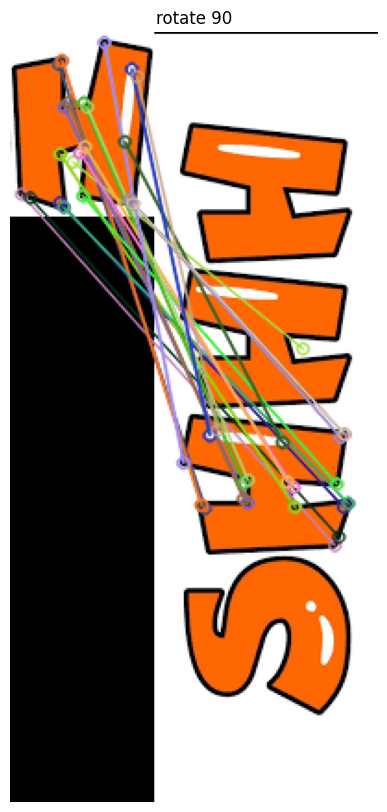

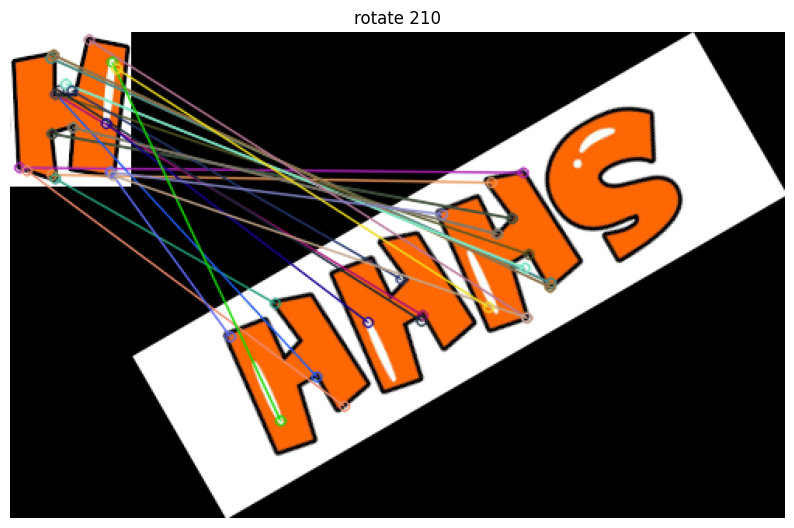

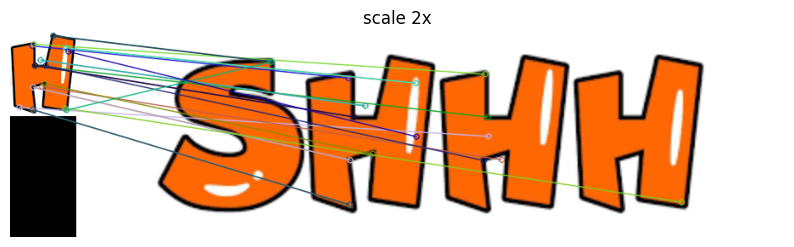

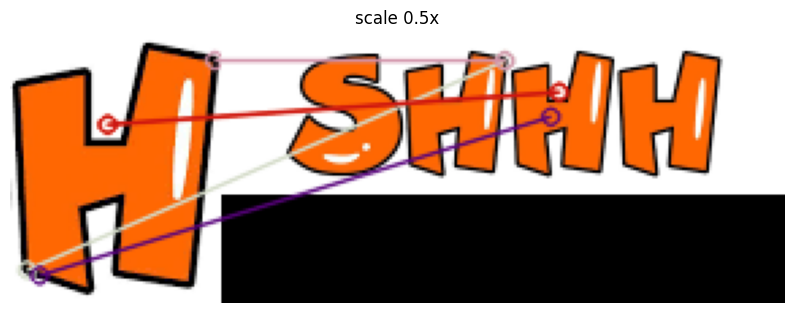

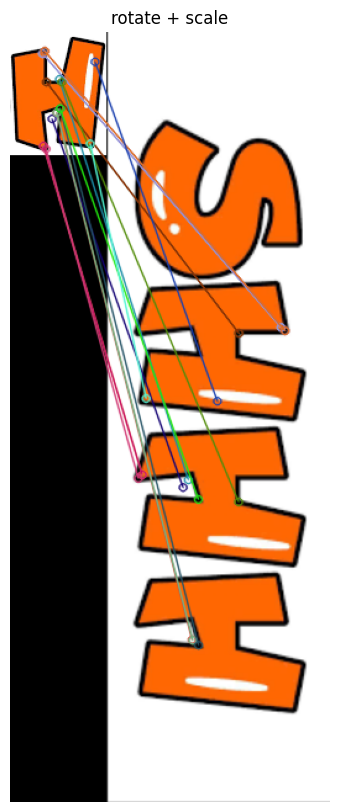

In [179]:
def match_and_show(transformed_img, title, template_img, kp_t, des_t, sift_detector, flann_matcher):
    
    kp_trans, des_trans = sift_detector.detectAndCompute(transformed_img, None)
    
    matches_trans = flann_matcher.knnMatch(des_t, des_trans, k=2)
    
    good_t = []
    coef = 0.8
    for m, n in matches_trans:
        if m.distance < coef * n.distance:
            good_t.append([m])
            
    res_img = cv2.drawMatchesKnn(template_img, kp_t, transformed_img, kp_trans, good_t, None, flags=2)
    show_img(res_img, title, size=10)


def rotate_image(image, angle, scale=1.0):
    h, w = image.shape[:2]
    center = (w / 2, h / 2)
    M = cv2.getRotationMatrix2D(center, angle, scale)
    abs_cos, abs_sin = abs(M[0, 0]), abs(M[0, 1])
    bound_w = int(h * abs_sin + w * abs_cos)
    bound_h = int(h * abs_cos + w * abs_sin)
    M[0, 2] += bound_w / 2 - center[0]
    M[1, 2] += bound_h / 2 - center[1]
    return cv2.warpAffine(image, M, (bound_w, bound_h))

img_a = rotate_image(img, 90)
match_and_show(img_a, "rotate 90", template, kp_t, des_t, sift, flann)

img_b = rotate_image(img, 210)
match_and_show(img_b, "rotate 210", template, kp_t, des_t, sift, flann)

img_c = cv2.resize(img, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_LINEAR)
match_and_show(img_c, "scale 2x", template, kp_t, des_t, sift, flann)

img_d = cv2.resize(img, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
match_and_show(img_d, "scale 0.5x", template, kp_t, des_t, sift, flann)

img_e = rotate_image(img, 270, scale=1.5)
match_and_show(img_e, "rotate + scale", template, kp_t, des_t, sift, flann)